In [0]:
#%pip install yfinance
%pip install TA-Lib

Looking in indexes: [REDACTED]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.2 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Descargando datos de AAPL desde 2022-08-20 hasta 2026-08-19...
✓ Datos descargados: 1001 registros


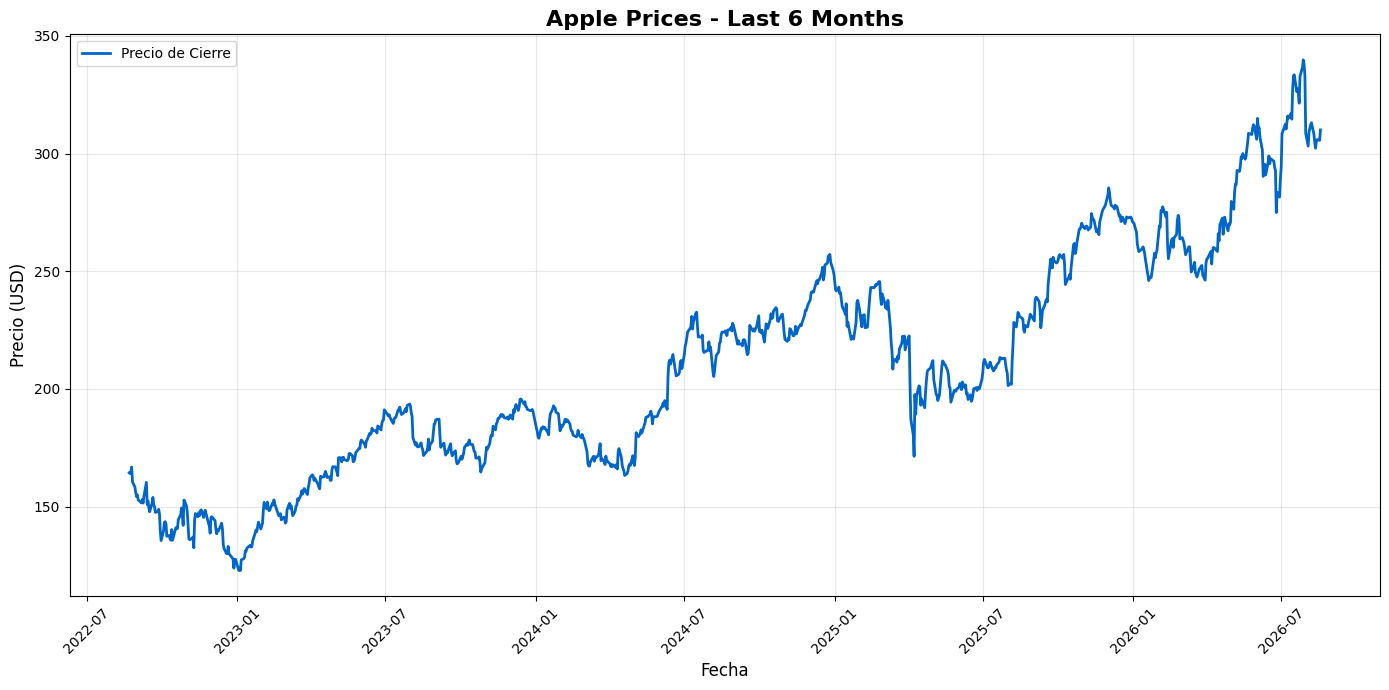

Close,High,Low,Open,Volume
164.35879516601562,166.6049043800519,163.9370276482697,166.43816395511286,69026800
164.0253143310547,165.47696339789675,163.4564272588674,163.87819481513557,54147100
164.31956481933594,164.88845187937156,163.06409508904346,164.11359750144874,53841500
166.7716522216797,166.8795448504242,165.12385385508654,165.54560642521002,51218200
160.48448181152344,167.7721056277997,160.42563400937078,167.3013082441995,78961000
158.28744506835938,159.77830620497173,156.7573420791942,158.0618418321346,73314000
155.86473083496094,159.4447780510849,154.6975330126192,159.02302554257605,77906200
154.2071533203125,157.50276536238007,154.1286845852179,157.23793525223348,87991100
154.93301391601562,155.38419053972876,151.70605191292117,153.63830193551485,74229900
152.8241424560547,157.2869518100939,152.0002433352291,156.6886409081276,76957800


In [0]:

from analisis_precios.data.downloader import FinancialDataDownloader
from analisis_precios.visualization.plotter import FinancialPlotter
from datetime import datetime, timedelta

end_date = datetime.today()
start_date = end_date - timedelta(days=365*4)

extractor = FinancialDataDownloader('AAPL')
df_apple = extractor.download_data(start_date=start_date.strftime('%Y-%m-%d'),
                                   end_date=end_date.strftime('%Y-%m-%d'))

plotter = FinancialPlotter(df_apple, ticker='AAPL')
plotter.plot_price_series(title="Apple Prices - Last 6 Months")

display(df_apple)

In [0]:
df_apple

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-20,264.108673,264.278384,257.700127,258.508681,42070500
2026-02-23,265.705811,268.950021,262.910811,263.020600,37308200
2026-02-24,271.655243,274.400344,267.233111,267.382838,47014600
2026-02-25,273.741516,274.450243,270.567158,271.295868,33714300
2026-02-26,272.463776,275.618120,270.317581,274.460213,32345100
...,...,...,...,...,...
2026-08-12,302.250000,305.660004,300.570007,305.100006,41657800
2026-08-13,305.260010,306.000000,302.049988,304.209991,40349300
2026-08-14,305.929993,307.489990,304.299988,306.000000,28229400


In [0]:
import talib

df_apple['SMA_21'] = talib.SMA(df_apple['Close'], timeperiod=21)
df_apple['SMA_63'] = talib.SMA(df_apple['Close'], timeperiod=63)

display(df_apple)

Close,High,Low,Open,Volume,SMA_21,SMA_63
164.35879516601562,166.6049043800519,163.9370276482697,166.43816395511286,69026800,null,null
164.0253143310547,165.47696339789675,163.4564272588674,163.87819481513557,54147100,null,null
164.31956481933594,164.88845187937156,163.06409508904346,164.11359750144874,53841500,null,null
166.7716522216797,166.8795448504242,165.12385385508654,165.54560642521002,51218200,null,null
160.48448181152344,167.7721056277997,160.42563400937078,167.3013082441995,78961000,null,null
158.28744506835938,159.77830620497173,156.7573420791942,158.0618418321346,73314000,null,null
155.86473083496094,159.4447780510849,154.6975330126192,159.02302554257605,77906200,null,null
154.2071533203125,157.50276536238007,154.1286845852179,157.23793525223348,87991100,null,null
154.93301391601562,155.38419053972876,151.70605191292117,153.63830193551485,74229900,null,null
152.8241424560547,157.2869518100939,152.0002433352291,156.6886409081276,76957800,null,null


In [0]:
df_apple['signal'] = None

cross_up = (df_apple['SMA_21'] > df_apple['SMA_63']) & (df_apple['SMA_21'].shift(1) <= df_apple['SMA_63'].shift(1))
cross_down = (df_apple['SMA_21'] < df_apple['SMA_63']) & (df_apple['SMA_21'].shift(1) >= df_apple['SMA_63'].shift(1))

df_apple.loc[cross_up, 'signal'] = 'BUY'
df_apple.loc[cross_down, 'signal'] = 'SELL'

df_apple

Price,Close,High,Low,Open,Volume,SMA_21,SMA_63,signal,position,log_return
Date,,,,,,,,,,
2022-08-22,164.358795,166.604904,163.937028,166.438164,69026800,NaN,NaN,None,0.0,NaN
2022-08-23,164.025314,165.476963,163.456427,163.878195,54147100,NaN,NaN,None,0.0,-0.002031
2022-08-24,164.319565,164.888452,163.064095,164.113598,53841500,NaN,NaN,None,0.0,0.001792
2022-08-25,166.771652,166.879545,165.123854,165.545606,51218200,NaN,NaN,None,0.0,0.014812
2022-08-26,160.484482,167.772106,160.425634,167.301308,78961000,NaN,NaN,None,0.0,-0.038428
...,...,...,...,...,...,...,...,...,...,...
2026-08-12,302.250000,305.660004,300.570007,305.100006,41657800,321.278608,308.223692,None,1.0,-0.008762
2026-08-13,305.260010,306.000000,302.049988,304.209991,40349300,320.232999,308.329209,None,1.0,0.009909
2026-08-14,305.929993,307.489990,304.299988,306.000000,28229400,318.945244,308.455827,None,1.0,0.002192


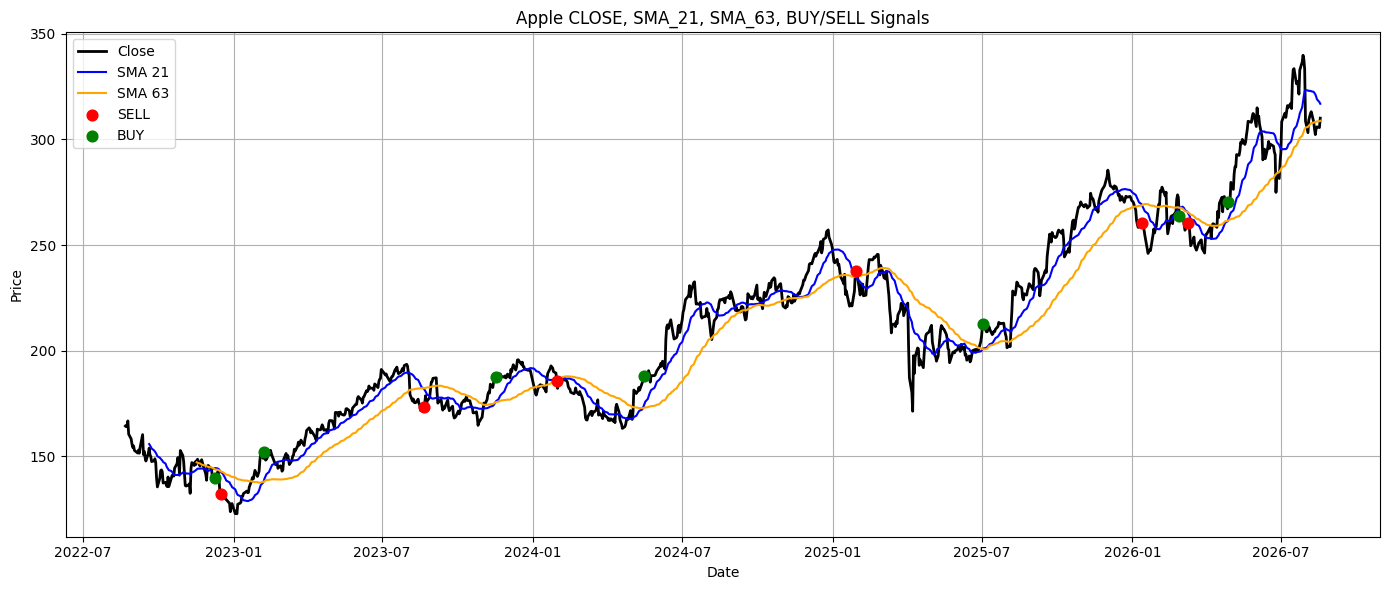

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df_apple.index, df_apple['Close'], label='Close', color='black', linewidth=2)
plt.plot(df_apple.index, df_apple['SMA_21'], label='SMA 21', color='blue')
plt.plot(df_apple.index, df_apple['SMA_63'], label='SMA 63', color='orange')

sell_idx = df_apple[df_apple['signal'] == 'SELL'].index
sell_prices = df_apple.loc[sell_idx, 'Close']
buy_idx = df_apple[df_apple['signal'] == 'BUY'].index
buy_prices = df_apple.loc[buy_idx, 'Close']

plt.scatter(sell_idx, sell_prices, color='red', marker='o', label='SELL', s=60, zorder=5)
plt.scatter(buy_idx, buy_prices, color='green', marker='o', label='BUY', s=60, zorder=5)

plt.legend()
plt.title('Apple CLOSE, SMA_21, SMA_63, BUY/SELL Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()

In [0]:
import numpy as np

# Columna de posición: la posición persiste hasta que cambie la señal
df_apple['position'] = df_apple['signal'].map({'BUY': 1, 'SELL': -1}).replace({None: np.nan}).ffill().fillna(0)

# Columna de crecimiento logarítmico del precio
df_apple['log_return'] = np.log(df_apple['Close'] / df_apple['Close'].shift(1))

display(df_apple)

Close,High,Low,Open,Volume,SMA_21,SMA_63,signal,position,log_return
164.35879516601562,166.6049043800519,163.9370276482697,166.43816395511286,69026800,null,null,null,0.0,null
164.0253143310547,165.47696339789675,163.4564272588674,163.87819481513557,54147100,null,null,null,0.0,-0.002031041941154517
164.31956481933594,164.88845187937156,163.06409508904346,164.11359750144874,53841500,null,null,null,0.0,0.0017923262139144516
166.7716522216797,166.8795448504242,165.12385385508654,165.54560642521002,51218200,null,null,null,0.0,0.014812426968369836
160.48448181152344,167.7721056277997,160.42563400937078,167.3013082441995,78961000,null,null,null,0.0,-0.03842827340897151
158.28744506835938,159.77830620497173,156.7573420791942,158.0618418321346,73314000,null,null,null,0.0,-0.013784598623531333
155.86473083496094,159.4447780510849,154.6975330126192,159.02302554257605,77906200,null,null,null,0.0,-0.015424131679661833
154.2071533203125,157.50276536238007,154.1286845852179,157.23793525223348,87991100,null,null,null,0.0,-0.010691671121322313
154.93301391601562,155.38419053972876,151.70605191292117,153.63830193551485,74229900,null,null,null,0.0,0.004696005285302968
152.8241424560547,157.2869518100939,152.0002433352291,156.6886409081276,76957800,null,null,null,0.0,-0.013704990605322888


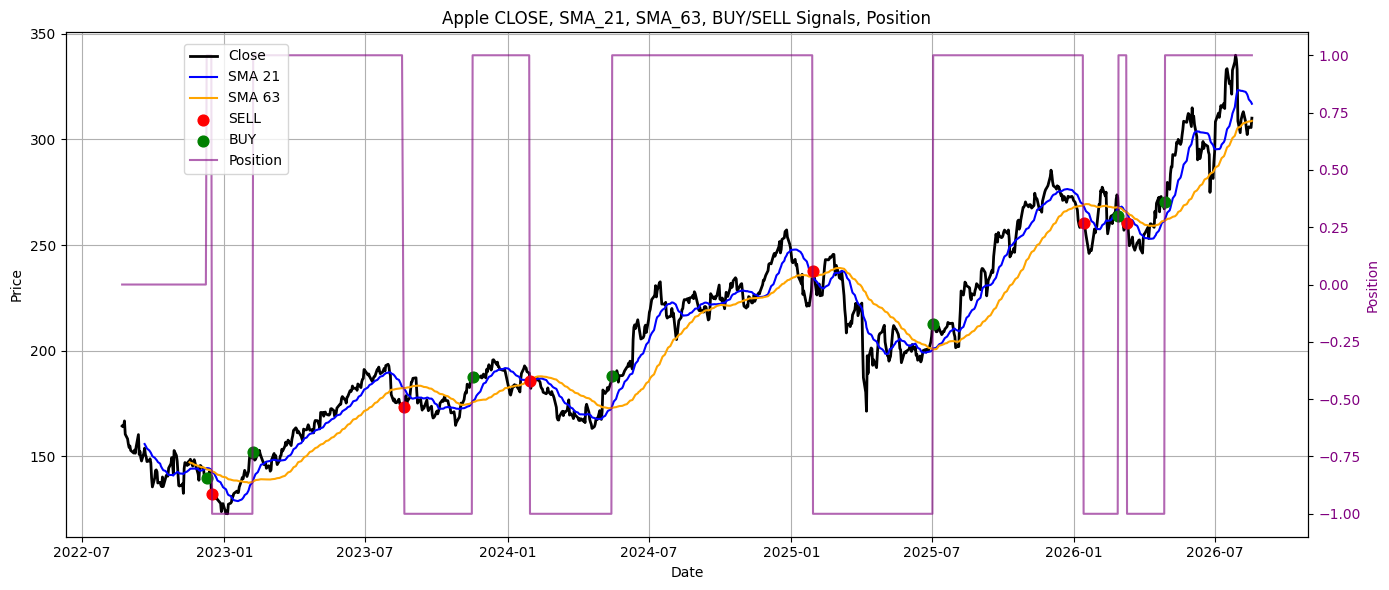

In [0]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_apple.index, df_apple['Close'], label='Close', color='black', linewidth=2)
ax1.plot(df_apple.index, df_apple['SMA_21'], label='SMA 21', color='blue')
ax1.plot(df_apple.index, df_apple['SMA_63'], label='SMA 63', color='orange')

sell_idx = df_apple[df_apple['signal'] == 'SELL'].index
sell_prices = df_apple.loc[sell_idx, 'Close']
buy_idx = df_apple[df_apple['signal'] == 'BUY'].index
buy_prices = df_apple.loc[buy_idx, 'Close']

ax1.scatter(sell_idx, sell_prices, color='red', marker='o', label='SELL', s=60, zorder=5)
ax1.scatter(buy_idx, buy_prices, color='green', marker='o', label='BUY', s=60, zorder=5)

ax2 = ax1.twinx()
ax2.plot(df_apple.index, df_apple['position'], label='Position', color='purple', linewidth=1.5, alpha=0.6)
ax2.set_ylabel('Position', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

fig.legend(loc='upper left', bbox_to_anchor=(0.13, 0.93))
ax1.set_title('Apple CLOSE, SMA_21, SMA_63, BUY/SELL Signals, Position')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.grid(True)
fig.tight_layout()
plt.show()

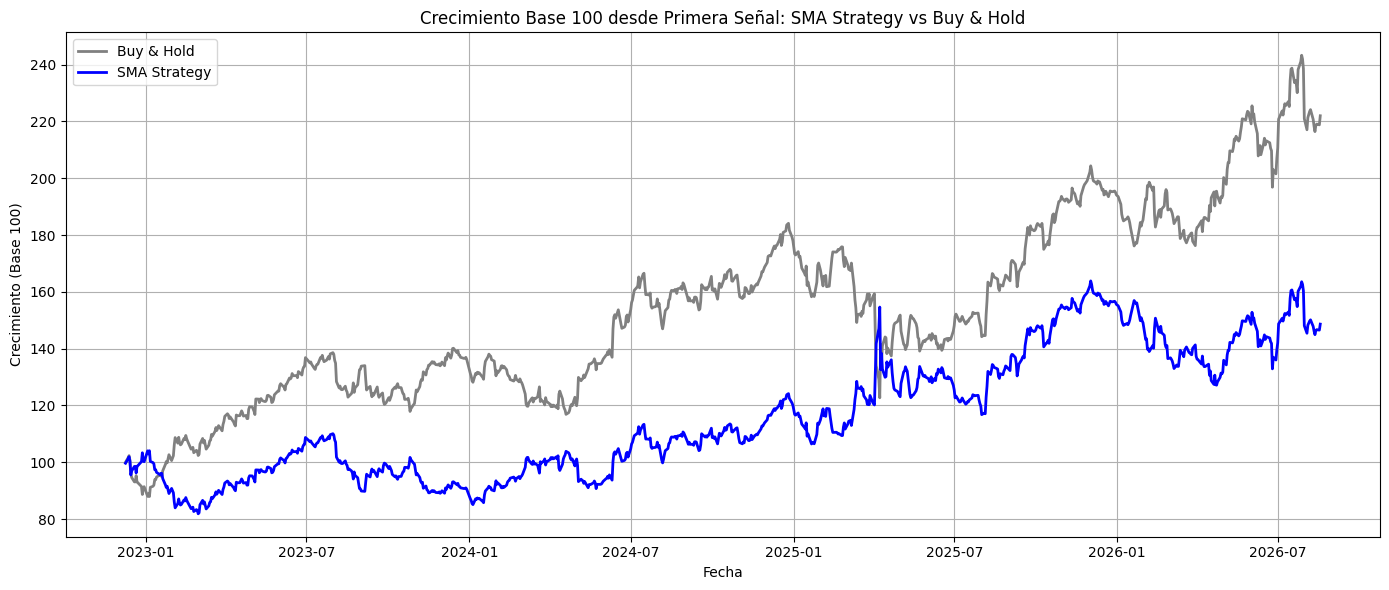

In [0]:
import matplotlib.pyplot as plt

# Encontrar el índice del primer día con señal
first_signal_idx = df_apple[df_apple['signal'].notna()].index[0]
first_signal_price = df_apple.loc[first_signal_idx, 'Close']

# Subset desde la primera señal
df_base = df_apple.loc[first_signal_idx:].copy()

# Base 100 para buy & hold
df_base['bh_growth'] = 100 * df_base['Close'] / first_signal_price

# Base 100 para estrategia sma
df_base['strategy_growth'] = 100 * (1 + df_base['position'] * df_base['log_return']).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(df_base.index, df_base['bh_growth'], label='Buy & Hold', color='gray', linewidth=2)
plt.plot(df_base.index, df_base['strategy_growth'], label='SMA Strategy', color='blue', linewidth=2)
plt.title('Crecimiento Base 100 desde Primera Señal: SMA Strategy vs Buy & Hold')
plt.xlabel('Fecha')
plt.ylabel('Crecimiento (Base 100)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [0]:
df_base

Price,Close,High,Low,Open,Volume,SMA_21,SMA_63,signal,position,log_return,bh_growth,strategy_growth
Date,,,,,,,,,,,,
2022-12-09,139.667053,143.017258,138.429139,139.843890,76097000,144.463813,143.840129,BUY,1.0,-0.003441,100.000000,99.655905
2022-12-12,141.956192,141.966011,138.586334,140.197574,70462700,144.352467,143.698293,None,1.0,0.016257,101.638997,101.276022
2022-12-13,142.919037,147.340125,141.710610,146.878366,93886200,144.154571,143.548853,None,1.0,0.006760,102.328383,101.960626
2022-12-14,140.698624,144.088120,138.684570,142.801095,82291200,143.917375,143.409941,None,1.0,-0.015658,100.738593,100.364115
2022-12-15,134.106293,139.313353,133.644534,138.635451,98931900,143.283919,143.192389,None,1.0,-0.047987,96.018560,95.547896
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-12,302.250000,305.660004,300.570007,305.100006,41657800,321.278608,308.223692,None,1.0,-0.008762,216.407516,144.926552
2026-08-13,305.260010,306.000000,302.049988,304.209991,40349300,320.232999,308.329209,None,1.0,0.009909,218.562648,146.362689
2026-08-14,305.929993,307.489990,304.299988,306.000000,28229400,318.945244,308.455827,None,1.0,0.002192,219.042348,146.683573


In [0]:
comparison_df = df_base[['bh_growth', 'strategy_growth']]

summary = {
    'Buy & Hold Growth (%)': (comparison_df['bh_growth'].iloc[-1] - comparison_df['bh_growth'].iloc[0]) / comparison_df['bh_growth'].iloc[0] * 100,
    'SMA Strategy Growth (%)': (comparison_df['strategy_growth'].iloc[-1] - comparison_df['strategy_growth'].iloc[0]) / comparison_df['strategy_growth'].iloc[0] * 100,
}

import pandas as pd
summary_df = pd.DataFrame([summary])

display(summary_df)

Buy & Hold Growth (%),SMA Strategy Growth (%)
121.97790504325255,49.14719230031942
